# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

In [4]:
!pip install transformers torch langchain langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 3.6 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 5.8 MB/s  0:00:19m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 6.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.3/661.3 kB 7.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 6.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 8.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━

## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [1]:
# YOUR CODE HERE
import pandas as pd

df = pd.read_csv("sampled_data.csv")
print(f"Loaded {len(df)} rows")

before = len(df)
df = df.dropna(subset=["instruction", "intent", "category"])
print(f"Removed {before - len(df)} rows with missing values")

before = len(df)
df["_norm"] = df["instruction"].str.lower().str.strip()
df = df.drop_duplicates(subset="_norm")
df = df.drop(columns="_norm")
print(f"Removed {before - len(df)} duplicate rows")

print(f"Final clean rows: {len(df)}")

Loaded 3902 rows
Removed 0 rows with missing values
Removed 0 duplicate rows
Final clean rows: 3902


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [2]:
# YOUR CODE HERE
df["instruction"] = df["instruction"].str.strip()

df["intent"] = df["intent"].str.strip().str.lower()

df["category"] = df["category"].str.strip().str.upper()

print(df[["instruction", "intent", "category"]].head())
print("\nUnique categories:", df["category"].unique())
print("Unique intents:", df["intent"].nunique())

                                         instruction  \
0                   I can't talk with  a human agent   
1  I have got to locate hte bills from {{Person N...   
2  I cannot pay, help me to inform of a problem w...   
3           I want help speaking to customer service   
4           I try to see th accepted payment options   

                     intent category  
0       contact_human_agent  CONTACT  
1             check_invoice  INVOICE  
2             payment_issue  PAYMENT  
3  contact_customer_service  CONTACT  
4     check_payment_methods  PAYMENT  

Unique categories: <ArrowStringArray>
[     'CONTACT',      'INVOICE',      'PAYMENT', 'SUBSCRIPTION',
       'CANCEL',      'ACCOUNT',       'REFUND',     'FEEDBACK',
     'DELIVERY',     'SHIPPING',        'ORDER']
Length: 11, dtype: str
Unique intents: 27


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [ ]:
# YOUR CODE HERE
from transformers import AutoTokenizer
import json

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
def to_chatml(row):
    target_json = json.dumps({
        "intent": row["intent"],
        "category": row["category"]
    })
    messages = [
        {"role": "user", "content": row["instruction"]},
        {"role": "assistant", "content": target_json},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False)
df["text"] = df.apply(to_chatml, axis=1)
print(df["text"].iloc[0])

/Users/abinas/Documents/projects/machine-learning/capstone-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant
{"intent": "contact_human_agent", "category": "CONTACT"}<|im_end|>



#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [10]:
# YOUR CODE HERE
import json
def extract_assistant_json(text):
    after = text.split("<|im_start|>assistant")[1]
    cleaned = after.replace("<|im_end|>","").strip()
    return cleaned

passed = 0
failed = 0
for i in range(3902):
    chunk = extract_assistant_json(df["text"].iloc[i])
    try:
        parsed = json.loads(chunk)
        passed += 1
    except json.JSONDecodeError:
        failed += 1
        print(f"Row {i} FAILED: {chunk}")

print(f"\nPassed: {passed} | Failed: {failed}")

example = extract_assistant_json(df["text"].iloc[0])
print("Parsed object:", json.loads(example))


Passed: 3902 | Failed: 0
Parsed object: {'intent': 'contact_human_agent', 'category': 'CONTACT'}


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [11]:
# YOUR CODE HERE
MAX_LENGTH = 128

def tokenize_row(text):
    enc = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
    )

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    labels = [
        token if mask == 1 else -100
        for token, mask in zip(input_ids, attention_mask)
    ]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

tokenized = df["text"].apply(tokenize_row)

# 4. Peek at row 0
print("input_ids:", tokenized.iloc[0]["input_ids"][:15], "...")
print("labels:   ", tokenized.iloc[0]["labels"][:15], "...")

input_ids: [151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525] ...
labels:    [151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525] ...


In [12]:
row = tokenized.iloc[0]

print("input_ids tail:", row["input_ids"][-15:])
print("labels tail:   ", row["labels"][-15:])

masked = sum(1 for x in row["labels"] if x == -100)
print(f"\nMasked (padding) slots: {masked} / {len(row['labels'])}")

input_ids tail: [151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643]
labels tail:    [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]

Masked (padding) slots: 74 / 128


#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

Max tokens:  67
Mean tokens: 55.2
Min tokens:  45

Rows at 128-token ceiling: 0 (0.0%)


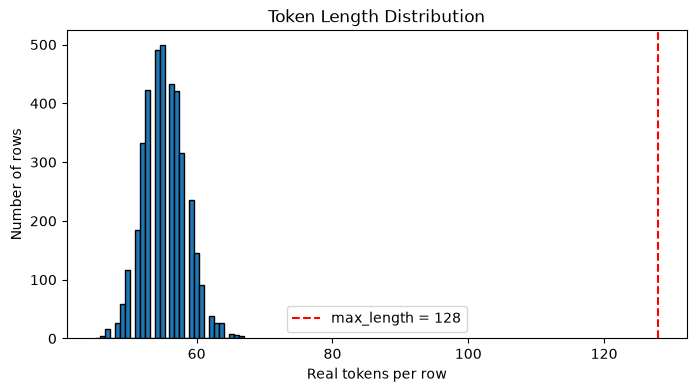

In [13]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

token_counts = tokenized.apply(lambda row: sum(row["attention_mask"]))

print(f"Max tokens:  {token_counts.max()}")
print(f"Mean tokens: {token_counts.mean():.1f}")
print(f"Min tokens:  {token_counts.min()}")

at_ceiling = (token_counts >= MAX_LENGTH).sum()
pct = at_ceiling / len(token_counts) * 100
print(f"\nRows at {MAX_LENGTH}-token ceiling: {at_ceiling} ({pct:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(token_counts, bins=30, edgecolor="black")
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"max_length = {MAX_LENGTH}")
plt.xlabel("Real tokens per row")
plt.ylabel("Number of rows")
plt.title("Token Length Distribution")
plt.legend()
plt.show()

#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [14]:
# YOUR CODE HERE
from langchain_community.document_loaders import TextLoader
import glob

md_files = glob.glob("Dataset/sop_documents/*.md")
print(f"Found {len(md_files)} markdown files")

documents = []
for path in md_files:
    loader = TextLoader(path)
    docs = loader.load()
    documents.extend(docs)

print(f"Loaded {len(documents)} documents\n")

print("Source:", documents[0].metadata["source"])
print("First 200 chars:\n", documents[0].page_content[:200])

/var/folders/96/jylj5rkx5n13cx5tm6mgdjc80000gn/T/ipykernel_5868/279008989.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


Found 13 markdown files
Loaded 13 documents

Source: Dataset/sop_documents/account_recovery.md
First 200 chars:
 # Account Recovery

## When To Use
Use this procedure when a customer cannot access their account due to a
lockout, a lost email address, suspected unauthorized access, or a disabled
account — anythin


### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [15]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

df = df.reset_index(drop=True)
df["tokenized"] = tokenized.values

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["intent"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["intent"],
    random_state=42,
)

print(f"Train: {len(train_df)}")
print(f"Valid: {len(val_df)}")
print(f"Test:  {len(test_df)}")

train_set = set(train_df["instruction"])
val_set   = set(val_df["instruction"])
test_set  = set(test_df["instruction"])

assert len(train_set & test_set) == 0,  "LEAK: train ∩ test"
assert len(train_set & val_set)  == 0,  "LEAK: train ∩ val"
assert len(val_set   & test_set) == 0,  "LEAK: val ∩ test"
print("\nZero leakage — all three piles are independent")

print("\nIntents per pile:")
print(f"  Train: {train_df['intent'].nunique()}")
print(f"  Valid: {val_df['intent'].nunique()}")
print(f"  Test:  {test_df['intent'].nunique()}")

Train: 3121
Valid: 390
Test:  391

Zero leakage — all three piles are independent

Intents per pile:
  Train: 27
  Valid: 27
  Test:  27


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [16]:
# YOUR CODE HERE
from datasets import Dataset, load_from_disk

# --- Helper: turn a split's tokenized column into a HuggingFace Dataset ---
def to_hf_dataset(split_df):
    rows = split_df["tokenized"].tolist()
    return Dataset.from_list(rows)

to_hf_dataset(train_df).save_to_disk("./tokenized_train")
to_hf_dataset(val_df).save_to_disk("./tokenized_valid")
to_hf_dataset(test_df).save_to_disk("./tokenized_test")
print("Saved tokenized_train / tokenized_valid / tokenized_test")

df_test = test_df[["text", "instruction", "intent", "category"]].copy()
df_test.to_csv("df_test.csv", index=False)
print(f"Saved df_test.csv ({len(df_test)} rows)")

reloaded = load_from_disk("./tokenized_train")
print(f"\nReloaded train: {len(reloaded)} rows, columns = {reloaded.column_names}")

Saving the dataset (1/1 shards): 100%|██████████| 391/391 [00:00<00:00, 31808.93 examples/s]

Saved tokenized_train / tokenized_valid / tokenized_test
Saved df_test.csv (391 rows)

Reloaded train: 3121 rows, columns = ['input_ids', 'attention_mask', 'labels']


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**